# Linear Regression & Gradient Descent

In this notebook we build linear regression from scratch with NumPy, train it with gradient descent, evaluate it, and compare it with the closed-form solution and scikit-learn.

Cells marked **TODO** ask you to write code. Each TODO is followed by a check cell that tests your work. Later sections reuse your functions, so complete the TODOs in order.

In [1]:
! pip3 install numpy
! pip3 install matplotlib
! pip3 install scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

## 1. Make synthetic data

We generate data from a known line so we can check whether our algorithm recovers it:

$$y = 4 + 3x + \text{noise}, \qquad \text{noise} \sim \mathcal{N}(0, 1)$$

The true parameters are $\theta_0 = 4$ (intercept) and $\theta_1 = 3$ (slope). With real data we never know the true parameters, which is why we need a learning algorithm.

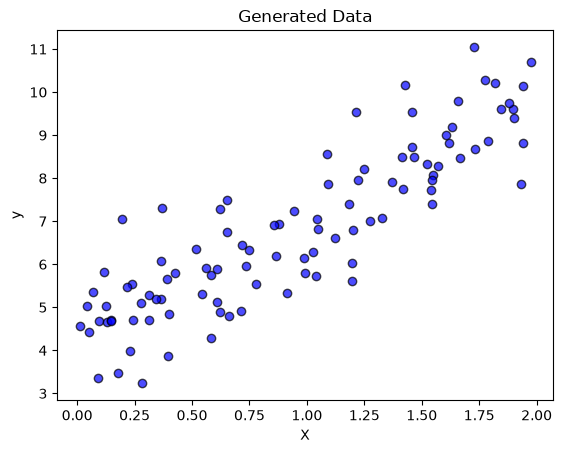

In [3]:
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # Independent variable
y = 4 + 3 * X + np.random.randn(100, 1) # Dependent variable (y = 4 + 3x + noise)

plt.scatter(X, y, color='blue', edgecolor='k', alpha=0.7)
plt.title("Generated Data")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

## 2. The Predictor & Cost Function (MSE)

**Notation**

- $m$ is the number of training examples (100 here).
- $X$ is the feature matrix with shape $(m, n+1)$, where $n$ is the number of features.
- $y$ is the target column with shape $(m, 1)$.
- $\theta$ is the parameter column $[\theta_0, \theta_1, \dots]$ with shape $(n+1, 1)$.

**The bias column.** The prediction is $\hat{y} = \theta_0 \cdot 1 + \theta_1 x$. If we add a column of ones to $X$, the intercept becomes just another weight and the whole model is one matrix product:

$$\hat{y} = X\theta$$

**The cost function.** To measure how wrong a given $\theta$ is, we use the mean squared error with an extra factor of one half:

$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)^2$$

Squaring makes every error positive and penalizes large errors more. The extra $\frac{1}{2}$ cancels the 2 that appears when we take the derivative in the next section. It does not change where the minimum is, but it means $J$ is exactly half of the usual MSE.

In [4]:
# Add x0 = 1 to each instance for the bias term (theta_0)
X_b = np.c_[np.ones((100, 1)), X]

print("X shape:", X.shape)
print("X_b shape:", X_b.shape)
print(X_b[:3])

X shape: (100, 1)
X_b shape: (100, 2)
[[1.         0.74908024]
 [1.         1.90142861]
 [1.         1.46398788]]


**TODO 1: Implement `predict` and `compute_cost`.**

Use vectorized NumPy (no loops over examples). Hint: `X.dot(theta)` or `X @ theta` does the matrix product.

In [5]:
def predict(X, theta):
    """Predicts y using the formula: y_hat = X * theta"""
    # TODO: return the predictions, shape (m, 1)
    raise NotImplementedError

def compute_cost(X, y, theta):
    """Calculates Mean Squared Error (MSE) with the 1/2 factor: J = 1/(2m) * sum((y_hat - y)^2)"""
    # TODO: return the cost as a single number
    raise NotImplementedError

Check TODO 1. The tiny dataset below has three points exactly on the line $y = 2x$, so we can work out the answers by hand.

In [6]:
X_small = np.array([[1., 1.], [1., 2.], [1., 3.]])
y_small = np.array([[2.], [4.], [6.]])
theta_perfect = np.array([[0.], [2.]])

assert predict(X_small, theta_perfect).shape == (3, 1), "predict should return shape (3, 1)"
assert np.allclose(predict(X_small, np.array([[1.], [1.]])), [[2.], [3.], [4.]]), "predict should compute X times theta"
assert np.isclose(compute_cost(X_small, y_small, theta_perfect), 0.0), "cost of a perfect fit should be 0"
assert np.isclose(compute_cost(X_small, y_small, np.zeros((2, 1))), 56 / 6), "cost at theta = 0 should be (4 + 16 + 36) / (2 * 3)"
assert np.ndim(compute_cost(X_small, y_small, theta_perfect)) == 0, "cost should be a single number"
print("TODO 1 passed")

NotImplementedError: 

**Try it by hand.** Below are three guesses for $(\theta_0, \theta_1)$. The legend shows the cost of each line. Edit the guesses and see how low you can push the cost.

In [ ]:
guesses = [(1.0, 1.0), (6.0, 0.5), (3.5, 3.2)] # (theta_0, theta_1)

x_line = np.linspace(0, 2, 50).reshape(-1, 1)
x_line_b = np.c_[np.ones((50, 1)), x_line]

plt.scatter(X, y, color='blue', edgecolor='k', alpha=0.5, label="data")
for t0, t1 in guesses:
    theta_guess = np.array([[t0], [t1]])
    cost = compute_cost(X_b, y, theta_guess)
    plt.plot(x_line, predict(x_line_b, theta_guess), label=f"theta = ({t0}, {t1}), cost = {cost:.2f}")
plt.legend()
plt.xlabel("X")
plt.ylabel("y")
plt.title("Lower cost means a better fit")
plt.show()

Guessing is hopeless once a model has many parameters, so we need a systematic way to reduce the cost. First, let's look at the cost for every pair $(\theta_0, \theta_1)$ on a grid. Each ring in the contour plot is a set of parameter values with the same cost.

In [ ]:
theta0_vals = np.linspace(-2, 8, 100)
theta1_vals = np.linspace(-2, 8, 100)
J_grid = np.zeros((len(theta1_vals), len(theta0_vals)))

for i, t1 in enumerate(theta1_vals):
    for j, t0 in enumerate(theta0_vals):
        J_grid[i, j] = compute_cost(X_b, y, np.array([[t0], [t1]]))

plt.contour(theta0_vals, theta1_vals, J_grid, levels=np.geomspace(0.5, J_grid.max(), 25), cmap='viridis')
plt.plot(4, 3, 'r*', markersize=12, label="true theta = (4, 3)")
plt.xlabel("Theta_0 (Intercept)")
plt.ylabel("Theta_1 (Slope)")
plt.title("Contours of the cost J(theta)")
plt.legend()
plt.show()

The cost surface is a single bowl with one lowest point near the true parameters (it is not exactly at (4, 3) because our data is a noisy sample). The rings are stretched into an ellipse because $\theta_0$ and $\theta_1$ are correlated: every $x$ is positive, so raising the intercept can be partly offset by lowering the slope.

## 3. Gradient Descent

- The Update Rule: $\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)$
- Learning Rate ($\alpha$)
- The Derivative ($\frac{\partial}{\partial \theta_j} J(\theta)$)

**Intuition.** Imagine standing on the bowl in fog. You cannot see the bottom, but you can feel which way the ground slopes. The gradient points uphill, so we repeatedly take a small step in the opposite direction. The learning rate $\alpha$ sets the size of each step.

**The derivative.** Differentiating $J$ with respect to $\theta_j$ gives

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)x_j^{(i)}$$

(the 2 from the chain rule cancels the $\frac{1}{2}$ in $J$). For all parameters at once, in matrix form:

$$\nabla_\theta J = \frac{1}{m} X^\top (X\theta - y)$$

The shapes work out: $X^\top$ is $(n+1, m)$ and $(X\theta - y)$ is $(m, 1)$, so the gradient is $(n+1, 1)$, the same shape as $\theta$. All parameters are updated simultaneously.

**TODO 2: Finish `gradient_descent`.**

Inside the loop, calculate the gradients and update `theta`. The rest of the function is given.

In [ ]:
def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = np.zeros(iterations)
    
    for i in range(iterations):
        predictions = predict(X, theta)
        
        # TODO: Calculate gradients
        raise NotImplementedError
        
        # TODO: Update weights (theta)
        raise NotImplementedError
        
        # Save cost for this iteration
        cost_history[i] = compute_cost(X, y, theta)
        
    return theta, cost_history

Check TODO 2. First we test the gradient numerically: nudge each parameter up and down by a tiny amount and see how the cost changes. This finite-difference estimate is slow but reliable, and it is a standard way to debug gradient code. We compare it with the gradient your function used in a single step (with `learning_rate = 1`, one step moves theta by exactly the gradient). Then we check that gradient descent recovers the line $y = 2x$ on the tiny dataset.

In [ ]:
def numerical_gradient(X, y, theta, eps=1e-5):
    grad = np.zeros_like(theta)
    for j in range(len(theta)):
        step = np.zeros_like(theta)
        step[j] = eps
        grad[j] = (compute_cost(X, y, theta + step) - compute_cost(X, y, theta - step)) / (2 * eps)
    return grad

theta_probe = np.array([[1.5], [-0.7]])
theta_after_one_step, _ = gradient_descent(X_b, y, theta_probe, 1.0, 1)
implied_gradient = theta_probe - theta_after_one_step

print("Gradient used by gradient_descent:", implied_gradient.ravel())
print("Numerical gradient:               ", numerical_gradient(X_b, y, theta_probe).ravel())
assert np.allclose(implied_gradient, numerical_gradient(X_b, y, theta_probe), atol=1e-6), "gradient does not match the numerical estimate"

theta_small, cost_small = gradient_descent(X_small, y_small, np.zeros((2, 1)), 0.1, 3000)
assert np.allclose(theta_small, [[0.], [2.]], atol=1e-2), "should recover theta = (0, 2) on the tiny dataset"

_, cost_small_short = gradient_descent(X_small, y_small, np.zeros((2, 1)), 0.05, 50)
assert np.all(np.diff(cost_small_short) < 0), "cost should decrease at every step"
print("TODO 2 passed")

Now run gradient descent on the data.

In [ ]:
# Initialize random weights
theta_initial = np.random.randn(2, 1)

# Set hyperparameters
learning_rate = 0.1
iterations = 100

# Run Gradient Descent
theta_best, cost_history = gradient_descent(X_b, y, theta_initial, learning_rate, iterations)

print(f"Optimized Weights via Gradient Descent:\n Theta_0 (Intercept): {theta_best[0][0]}\n Theta_1 (Slope): {theta_best[1][0]}")

In [ ]:
plt.figure(figsize=(12, 4))

# The line before and after training
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='blue', edgecolor='k', alpha=0.5)
plt.plot(x_line, predict(x_line_b, theta_initial), 'k--', label="initial")
plt.plot(x_line, predict(x_line_b, theta_best), 'r', linewidth=2, label="after gradient descent")
plt.title("Fitted line")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

# Cost at every iteration
plt.subplot(1, 2, 2)
plt.plot(cost_history)
plt.title("Cost vs. iteration")
plt.xlabel("Iteration")
plt.ylabel("Cost J(theta)")

plt.show()

**Choosing the learning rate.** $\alpha$ is a hyperparameter: we choose it, the algorithm does not learn it. The cell below trains with five different learning rates from the same starting point (the y-axis is on a log scale).

In [ ]:
alphas = [0.001, 0.01, 0.1, 0.5, 1.0]

for a in alphas:
    _, history = gradient_descent(X_b, y, theta_initial, a, 100)
    plt.plot(history, label=f"alpha = {a}")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Cost J(theta) (log scale)")
plt.title("Effect of the learning rate")
plt.legend()
plt.show()

**Questions to think about**

1. What happens to training when $\alpha$ is too small? When it is too large? How can you tell from the cost curve alone?
2. Try adding `0.9` and `0.95` to `alphas`. Is a bigger learning rate always faster? Where does training break down?
3. Suppose the cost goes down for 50 iterations and then starts to go up. What are two possible reasons?

## 4. Evaluation

Four standard regression metrics (with $\bar{y}$ the mean of the true values):

| Metric | Formula | Meaning |
|---|---|---|
| MSE | $\frac{1}{m}\sum(\hat{y} - y)^2$ | Average squared error (units of $y^2$) |
| RMSE | $\sqrt{\text{MSE}}$ | Typical error size, in the units of $y$ |
| MAE | $\frac{1}{m}\sum\lvert\hat{y} - y\rvert$ | Average absolute error |
| R-Squared | $1 - \dfrac{\sum(y - \hat{y})^2}{\sum(y - \bar{y})^2}$ | Fraction of the variance in $y$ explained by the model (1 is perfect, 0 is no better than always predicting the mean) |

Note that MSE here has no factor of $\frac{1}{2}$, unlike the cost $J$.

In [ ]:
y_pred = predict(X_b, theta_best)

**TODO 3: Compute the four metrics by hand** using only NumPy (no scikit-learn). Store them in `mse`, `rmse`, `mae` and `r2`.

In [ ]:
# TODO: compute the metrics from y and y_pred using NumPy
mse = None
rmse = None
mae = None
r2 = None
raise NotImplementedError

In [ ]:
print("Evaluation Metrics")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R-Squared: {r2}")

Check TODO 3 against scikit-learn.

In [ ]:
mse_sk = mean_squared_error(y, y_pred)
rmse_sk = np.sqrt(mse_sk)
mae_sk = mean_absolute_error(y, y_pred)
r2_sk = r2_score(y, y_pred)

assert np.isclose(mse, mse_sk), "MSE does not match scikit-learn"
assert np.isclose(rmse, rmse_sk), "RMSE does not match scikit-learn"
assert np.isclose(mae, mae_sk), "MAE does not match scikit-learn"
assert np.isclose(r2, r2_sk), "R-Squared does not match scikit-learn"
print("TODO 3 passed")

The data was generated with noise of standard deviation 1, and no model can predict random noise, so the best possible RMSE is about 1. An RMSE close to 1 means the line has learned essentially everything that can be learned.

A residual is $y - \hat{y}$. If a straight line is the right model, the residuals should look like patternless noise centered on zero.

In [ ]:
residuals = (y - y_pred).ravel()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, color='blue', edgecolor='k', alpha=0.7)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Predicted y")
plt.ylabel("Residual (y - y_pred)")
plt.title("Residuals vs. predictions")

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=12, edgecolor='k')
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Distribution of residuals")

plt.show()

## 6. Multiple Linear Regression

With more than one feature, nothing in our code needs to change: $X$ simply has more columns and $\theta$ has more entries.

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n = X\theta$$

We scikit-learn again.

In [ ]:
print("Multiple Linear Regression")
np.random.seed(42)
# Generate multi-variable data: y = 3 + 2*x1 + 5*x2 + noise
X_multi = 2 * np.random.rand(100, 2)
y_multi = 3 + 2 * X_multi[:, 0:1] + 5 * X_multi[:, 1:2] + np.random.randn(100, 1)

# Train the model
multi_lin_reg = LinearRegression()
multi_lin_reg.fit(X_multi, y_multi)

print(f"Intercept (Theta_0): {multi_lin_reg.intercept_[0]}")
print(f"Coefficients (Theta_1, Theta_2): {multi_lin_reg.coef_[0][0]}, {multi_lin_reg.coef_[0][1]}")